In [1]:
%run -i ../../python_scripts/nb_setup.py

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


#### Loading WSI images 

3 classes : 

* ADIMUC : loose non-tumor tissue
* STRMUS : dense non-tumor tissue
* TUMSTU : tumor tissue

We regroup ADIMUC and STRMUS classes into class 0 (non-tumor tissue), TUMSTU images are labelled class 1 (tumor tissue)

We train a simple cnn model to classify the samples into class 0 or class 1, before testing our bounds

In [ ]:
# Replace with your actual dataset path
DATASET_ROOT = 'PATH_WHERE_TO_STORE_WSI_IMAGES_ON_YOUR_MACHINE' # download at https://zenodo.org/records/2530789

# Compute mean and std
mean, std = compute_mean_std(DATASET_ROOT)
print("Mean:", mean)
print("Std:", std)

# Your transforms
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_set, val_set, test_set = split_and_balance_dataset(
    root=DATASET_ROOT,
    transform=transform,
    train_size=1/3,
    val_size=1/10
)

# Dataloaders
train_loader = DataLoader(train_set, batch_size=15, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=15, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=15, shuffle=False, num_workers=2)

100%|██████████| 1198/1198 [01:33<00:00, 12.85it/s]

Mean: tensor([0.7801, 0.6251, 0.7518])
Std: tensor([0.1205, 0.1491, 0.1078])


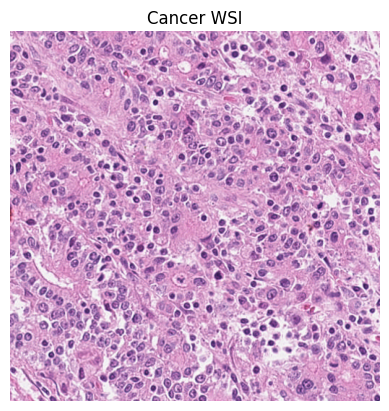

In [3]:
cancer_folder = os.path.join(DATASET_ROOT, 'TUMSTU')
image_files = [f for f in os.listdir(cancer_folder) if f.endswith('.png')]
random_image = rd.choice(image_files)
image_path = os.path.join(cancer_folder, random_image)
img = mpimg.imread(image_path)
plt.imshow(img)
plt.title('Cancer WSI')
plt.axis('off')  # Turn off axis
plt.show()

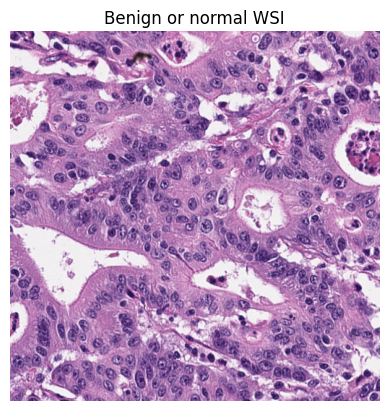

In [4]:
non_cancer_folder = os.path.join(DATASET_ROOT, 'ADIMUC_STRMUS')
image_files = [f for f in os.listdir(cancer_folder) if f.endswith('.png')]
random_image = rd.choice(image_files)
image_path = os.path.join(cancer_folder, random_image)
img = mpimg.imread(image_path)
plt.imshow(img)
plt.title('Benign or normal WSI')
plt.axis('off')  # Turn off axis
plt.show()

In [6]:
train_counts = count_labels(train_set)
val_counts = count_labels(val_set)
test_counts = count_labels(test_set)

print("Train set: ", train_counts)
print("Val set:   ", val_counts)
print("Test set:  ", test_counts)

Train set:  {0: 2637, 1: 2637}
Val set:    {0: 806, 1: 806}
Test set:   {0: 4534, 1: 2254}


#### Training small CNN for cancer detection task

In [7]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SmallCNN(nn.Module):
    def __init__(self, p=0.2):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 20, 4, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p)
        self.dropout2d = nn.Dropout2d(p)
        self.conv2 = nn.Conv2d(20, 32, 4, padding=1)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.dropout = nn.Dropout(p)            # train-time and MC-dropout layer
        self.fc1 = nn.Linear(32 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.dropout2d(self.conv2(x))))
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.dropout(self.fc1(x)))   # dropout used here
        x = self.fc2(x)
        return x


# Initialize the model
cnn = SmallCNN().to(device)

In [ ]:
# Define Loss, Optimizer and lr scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-4)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=0)

# Training Loop
num_epochs = 1
for epoch in range(num_epochs):
    cnn.train()
    running_loss = 0
    correct = 0
    total = 0

    print('TRAINING EPOCH', epoch)
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
            
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
    print(f"Train Accuracy: {100 * correct / total:.2f}%")

    # Evaluate cnn at the end of current epoch
    cnn.eval()
    correct = 0
    total = 0
    print('TESTING')
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = cnn(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    print(f"Validation Accuracy: {100 * correct / total:.2f}%")
    scheduler.step(correct)

    torch.save(cnn.state_dict(), "PATH_WHERE_TO_STORE_WSI_WEIGHTS_ON_YOUR_MACHINE/cnn_wsi_binary_epoch"+str(epoch)+".pth")

TRAINING EPOCH 0


100%|██████████| 352/352 [00:34<00:00, 10.07it/s]


Epoch [1/1], Loss: 0.3340
Train Accuracy: 85.53%
TESTING
Validation Accuracy: 91.69%


#### Retrieving Softmax Response, Predicted class and True class for all samples in CNN test set 

In [ ]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load trained cnn
cnn = SmallCNN().to(device)
checkpoint = torch.load("PATH_WHERE_TO_STORE_WSI_WEIGHTS_ON_YOUR_MACHINE/cnn_wsi_binary_epoch0.pth")
cnn.load_state_dict(checkpoint)

<All keys matched successfully>

In [10]:
sgp_dico_test = prepare_sgp_dico(test_loader, model = cnn, device = device, T = 1)
sgp_set = pd.DataFrame(sgp_dico_test)

100%|██████████| 453/453 [00:42<00:00, 10.64it/s]


In [11]:
sgp_set.sort_values('kappa')

,y_true,y_pred,kappa
5250,0.0,1.0,0.500626
3810,0.0,0.0,0.501781
958,0.0,1.0,0.502011
431,0.0,0.0,0.502261
6030,1.0,0.0,0.502373
...,...,...,...
4730,0.0,0.0,0.999991
2252,0.0,0.0,0.999991
6494,0.0,0.0,0.999991
5939,0.0,0.0,0.999992


#### Displaying evolution of accuracy with respect to SR thresholding (should be strictly increasing: more confidence $\Rightarrow$ less errors)

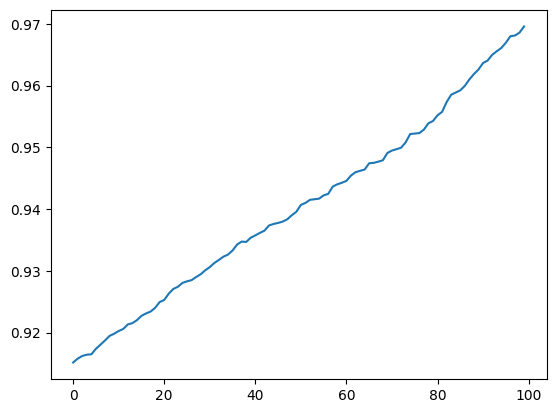

In [13]:
accs=[]
for theta in np.linspace(0.5,0.9,num=100):
    selected = sgp_set.loc[sgp_set.kappa >= theta].copy()
    accs.append((selected.y_true==selected.y_pred).sum()/selected.shape[0])
plt.plot(accs)
plt.show()

In [14]:
pickle.dump(sgp_set, open('sgp_set_cnn','wb'))

#### Retrieving MC dropout negative of the variance (MCD), Predicted class and True class for all samples in CNN test set 

In [15]:
sgp_set = pickle.load(open('sgp_set_cnn', 'rb'))

In [16]:
y_pred_det, mean_p, var_p = mc_var_for_deployed_class(cnn, test_loader, device, T=30)

Deterministic pass: 100%|██████████| 453/453 [00:39<00:00, 11.33it/s]


In [17]:
sgp_set['kappa'] = -var_p.numpy()

#### Displaying evolution of accuracy with respect to MCD thresholding (should be strictly increasing: more confidence $\Rightarrow$ less errors)

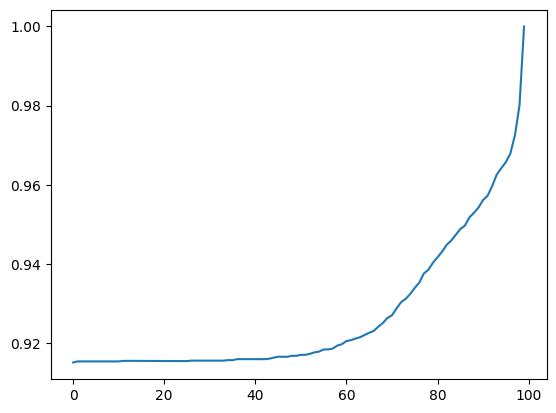

In [20]:
accs = []
for t in np.linspace(sgp_set.kappa.min(), sgp_set.kappa.max(), num = 100):
    selected = sgp_set.loc[sgp_set.kappa >= t].copy()
    accs.append((selected.y_true==selected.y_pred).sum()/selected.shape[0])
plt.plot(accs)
plt.show()

In [21]:
pickle.dump(sgp_set.reset_index(drop=True), open('sgp_set_cnn_MCD','wb'))